행은 slicing, loc 으로 가지고 오고, 열은 걸럼 이름을 가지고 온다.
둘다 2개 이상이면 [] 로 감싸서 가지고 온다

In [36]:
import pandas as pd

path = 'https://github.com/dongupak/DataML/raw/main/csv/'
file = path+'vehicle_prod.csv'
df = pd.read_csv(file, index_col=0)   # 원격지에 접속하여 csv를 읽어옴
df_3 = df.head(3)     # 첫 3행의 정보를 가져온다
df_3

,2007,2008,2009,2010,2011
China,7.71,7.95,11.96,15.84,16.33
EU,19.02,17.71,15.00,16.70,17.48
US,10.47,8.45,5.58,7.60,8.40


In [35]:
df['2007']

China      7.71
EU        19.02
US        10.47
Japan     10.87
Korea      4.04
Mexico     2.01
Name: 2007, dtype: float64

In [7]:
df.columns # pandas 의 index 객체로 준다.
df.columns.tolist() # python 의 list 로 반환 해준다.

['2007', '2008', '2009', '2010', '2011']

### loc[행, 열] 구조임을 명심하자

In [11]:
df['2008']        # Series
df[['2008','2009']]  # Data Frame

,2008,2009
China,7.95,11.96
EU,17.71,15.00
US,8.45,5.58
Japan,10.83,7.55
Korea,3.78,3.45
Mexico,2.05,1.50


In [31]:
df['2008']        # Series
df[['2008','2009']]  # Data Frame

,2008,2009
China,7.95,11.96
EU,17.71,15.00
US,8.45,5.58
Japan,10.83,7.55
Korea,3.78,3.45
Mexico,2.05,1.50


In [30]:
df.loc['Korea', '2011']
df.loc[['Korea','EU']]

,2007,2008,2009,2010,2011
Korea,4.04,3.78,3.45,4.2,4.62
EU,19.02,17.71,15.00,16.7,17.48


In [32]:
df.head(3)['2008'] # head(), tail() 는 df 의 행/렬 연산과 함께 사용할수 있다.

China     7.95
EU       17.71
US        8.45
Name: 2008, dtype: float64

loc, iloc 내부에서
1. slicing 을 하려면 [0, 0:3] 이런식으로 함 (부분 리스트가 여기서는 안쓰임)
2. 부분 리스트를 넣는 경우에는 [0,[0,1,2]] 이렇게

In [33]:
df.iloc[0,1:3] # 0행 china, 1,2 열 2008, 2009 이다.

2008     7.95
2009    11.96
Name: China, dtype: float64

In [39]:
df.iloc[0,3]

np.float64(15.84)

In [43]:
df.loc['China':'US', '2009':'2011'] # lable 슬라이스는 끝값을 포함한다.

,2009,2010,2011
China,11.96,15.84,16.33
EU,15.00,16.70,17.48
US,5.58,7.60,8.40


In [44]:
df.iloc[0:1,0:1] # 일반적인 슬라이싱은 적용 안됨

,2007
China,7.71


In [48]:
filt = df['2007']> 10
df[filt] # logical index 를 사용한 indexing

,2007,2008,2009,2010,2011
EU,19.02,17.71,15.00,16.70,17.48
US,10.47,8.45,5.58,7.60,8.40
Japan,10.87,10.83,7.55,9.09,7.88


In [55]:
df.drop('2007', axis=1) # inplace 를 해주어야 한다
df.drop('2007', axis=1, inplace=True) # 요즘은 df = drop('2007', axis = 1 ) 을 주로 사용한다.

In [66]:
# 2008 년 부터 2011 년 까지의 총 생산 대수와 평균을 다시 계산한다.
df['total'] = df[['2008', '2009', '2010', '2011']].sum(axis=1)
df
df['mean'] = df[['2008', '2009', '2010', '2011']].mean(axis=1)
df

,2008,2009,2010,2011,total,mean
China,7.95,11.96,15.84,16.33,52.08,13.0200
EU,17.71,15.00,16.70,17.48,66.89,16.7225
US,8.45,5.58,7.60,8.40,30.03,7.5075
Japan,10.83,7.55,9.09,7.88,35.35,8.8375
Korea,3.78,3.45,4.20,4.62,16.05,4.0125
Mexico,2.05,1.50,2.25,2.54,8.34,2.0850


In [67]:
d_df =pd.DataFrame(data = [[10,20,30,40],[50,60,70,80]], columns = ['A', 'B', 'C', 'D'])
d_df

In [72]:
d_df.drop('B',axis=1, inplace=True)
d_df

,A,C,D
0,10,30,40
1,50,70,80


<Axes: >

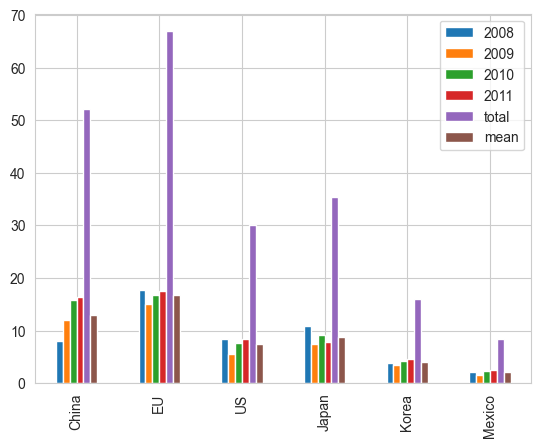

In [75]:
df.plot.bar()

<Axes: >

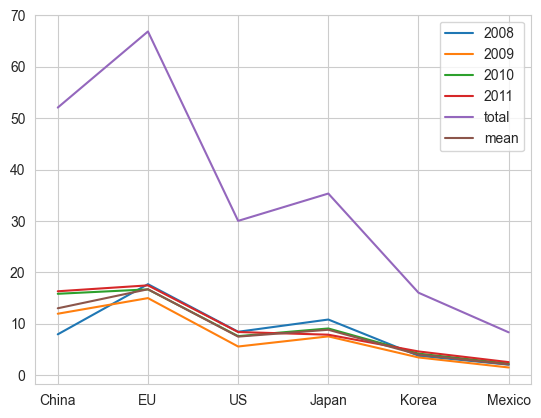

In [76]:
df.plot.line()

In [77]:
     df.transpose()

,China,EU,US,Japan,Korea,Mexico
2008,7.95,17.7100,8.4500,10.8300,3.7800,2.050
2009,11.96,15.0000,5.5800,7.5500,3.4500,1.500
2010,15.84,16.7000,7.6000,9.0900,4.2000,2.250
2011,16.33,17.4800,8.4000,7.8800,4.6200,2.540
total,52.08,66.8900,30.0300,35.3500,16.0500,8.340
mean,13.02,16.7225,7.5075,8.8375,4.0125,2.085


<Axes: >

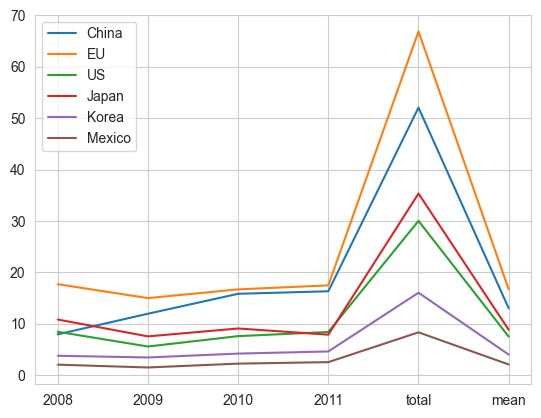

In [78]:
df.transpose().plot.line()

<Axes: >

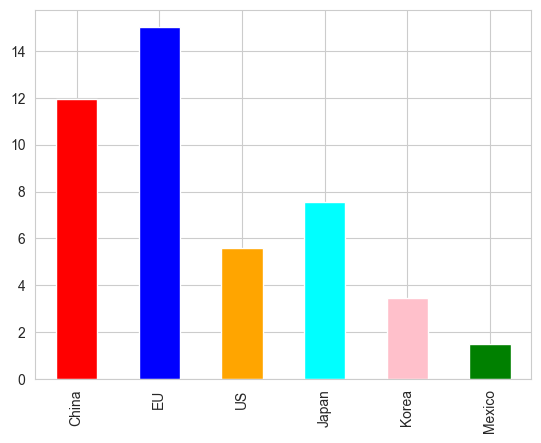

In [83]:
df['2009'].plot.bar(color= ['red', 'blue', 'orange','cyan','pink','green'])

<Axes: >

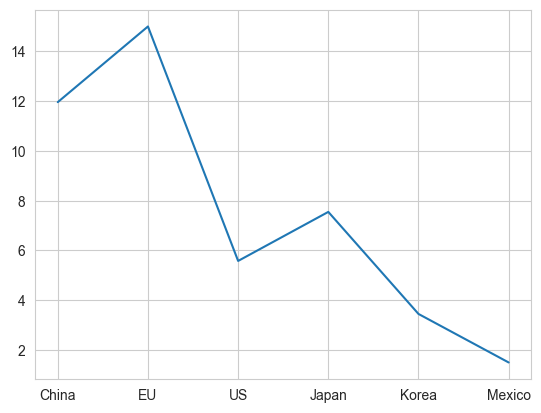

In [84]:
df['2009'].plot.line()